<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [2]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [3]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print("Acurácia no treino:", train_acc)
print("Acurácia no teste:", test_acc)

Acurácia no treino: 1.0
Acurácia no teste: 0.9333333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

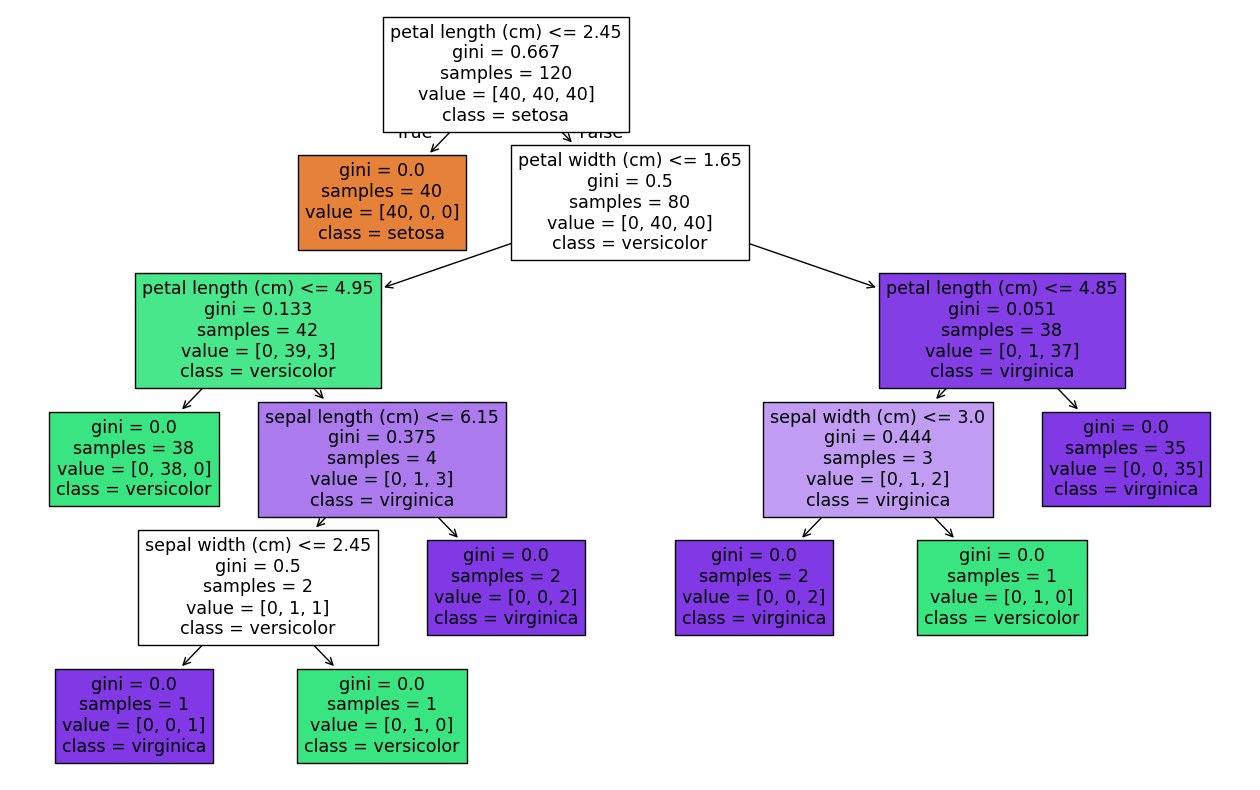

Atributo na raiz: petal length (cm)
Profundidade da árvore: 5


In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 10))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.show()

raiz = iris.feature_names[model.tree_.feature[0]]
profundidade = model.get_depth()

print("Atributo na raiz:", raiz)
print("Profundidade da árvore:", profundidade)

O atributo que aparece na raiz é o impresso acima pela variável "raiz".
A profundidade da árvore é o valor impresso acima pela variável "profundidade".
Esses valores foram obtidos diretamente do modelo treinado.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [5]:
resultados = []

profundidades = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]

for depth in profundidades:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    profundidade_arvore = clf.get_depth()
    numero_folhas = clf.get_n_leaves()
    
    resultados.append({
        "max_depth": depth,
        "acuracia_treino": acc_train,
        "acuracia_teste": acc_test,
        "profundidade_arvore": profundidade_arvore,
        "numero_folhas": numero_folhas
    })

tabela_resultados = pd.DataFrame(resultados)
tabela_resultados

,max_depth,acuracia_treino,acuracia_teste,profundidade_arvore,numero_folhas
0,1.0,0.666667,0.666667,1,2
1,2.0,0.966667,0.933333,2,3
2,3.0,0.983333,0.966667,3,5
3,4.0,0.991667,0.933333,4,7
4,5.0,1.000000,0.933333,5,8
5,6.0,1.000000,0.933333,5,8
6,7.0,1.000000,0.933333,5,8
7,8.0,1.000000,0.933333,5,8
8,9.0,1.000000,0.933333,5,8
9,NaN,1.000000,0.933333,5,8


O overfitting começa quando a acurácia no treino continua aumentando, mas a acurácia no teste deixa de melhorar ou passa a oscilar/cair. Em árvores de decisão, isso tende a acontecer em profundidades maiores, porque o modelo fica mais complexo e começa a memorizar padrões específicos do conjunto de treino.

Quando max_depth=None, a árvore pode crescer livremente até separar os dados de treino da forma mais detalhada possível. Por isso, ela consegue atingir 100% de acurácia no treino: o modelo praticamente memoriza os exemplos vistos. Porém, isso não significa melhor generalização, pois essa memorização pode prejudicar o desempenho em dados novos.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [6]:
resultados_criterio = []

for criterio in ["gini", "entropy"]:
    clf = DecisionTreeClassifier(criterion=criterio, random_state=42)
    clf.fit(X_train, y_train)
    
    y_pred_test = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred_test)
    profundidade = clf.get_depth()
    
    resultados_criterio.append({
        "criterion": criterio,
        "profundidade_arvore": profundidade,
        "acuracia_teste": acc
    })

tabela_criterios = pd.DataFrame(resultados_criterio)
tabela_criterios

,criterion,profundidade_arvore,acuracia_teste
0,gini,5,0.933333
1,entropy,5,0.933333


Os modelos com criterion="gini" e criterion="entropy" foram comparados em termos de profundidade da árvore e acurácia. A diferença entre eles ocorre porque cada critério mede a impureza de forma diferente durante a escolha das divisões.

O critério Gini tende a ser um pouco mais simples computacionalmente, enquanto o critério Entropy utiliza ganho de informação baseado em entropia. Neste experimento, a comparação deve ser feita observando diretamente a tabela gerada. Caso as métricas sejam muito próximas, isso indica que, para o dataset Iris, ambos os critérios produzem árvores com desempenho semelhante.

# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [7]:
resultados_leaf = []

valores_min_samples_leaf = [1, 2, 3, 4, 5, 6, 8, 10]

for leaf in valores_min_samples_leaf:
    clf = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )
    clf.fit(X_train, y_train)
    
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    profundidade = clf.get_depth()
    folhas = clf.get_n_leaves()
    
    resultados_leaf.append({
        "min_samples_leaf": leaf,
        "acuracia_treino": acc_train,
        "acuracia_teste": acc_test,
        "profundidade_arvore": profundidade,
        "numero_folhas": folhas
    })

tabela_leaf = pd.DataFrame(resultados_leaf)
tabela_leaf

,min_samples_leaf,acuracia_treino,acuracia_teste,profundidade_arvore,numero_folhas
0,1,1.000000,0.933333,5,8
1,2,0.983333,0.933333,4,6
2,3,0.983333,0.966667,3,5
3,4,0.983333,0.966667,3,5
4,5,0.966667,0.933333,3,5
5,6,0.966667,0.933333,3,5
6,8,0.966667,0.933333,3,5
7,10,0.966667,0.933333,3,5


Nesta análise, foi escolhido o hiperparâmetro min_samples_leaf, que controla o número mínimo de amostras exigidas em cada folha da árvore. Esse parâmetro influencia diretamente a complexidade do modelo, pois valores maiores tendem a restringir o crescimento da árvore.

Observando os resultados, nota-se que valores menores de min_samples_leaf permitem árvores mais profundas e com mais folhas, o que geralmente aumenta a acurácia no treino, mas também pode aumentar o risco de overfitting. Já valores maiores simplificam a árvore, reduzindo profundidade e número de folhas, o que pode melhorar a generalização, embora em excesso também possa causar underfitting.

O melhor modelo encontrado deve ser identificado pela maior acurácia no teste. Seus parâmetros e métricas estão mostrados na tabela e no resumo impresso acima.